# AutoIntel AI – Intelligent Vehicle Diagnosis and Maintenance Assistant
## Module 03 : OBD-II Knowledge Base — Standardization & Repair Knowledge Generation
**Industrial Training Project | Member 1 — Data Processing & Feature Engineering | Week 2**

---

### 1. Project Introduction

This notebook covers the **Week 2** OBD-II responsibilities for **Member 1 (Data Processing & Feature
Engineering)** on the AutoIntel AI project:

1. Standardize the OBD-II fault code knowledge base (`obd_knowledge.csv`).
2. Engineer diagnosis-ready features on top of it (severity ordinal, higher-level system grouping).
3. Build a new **repair knowledge base** (`repair_knowledge.csv`) that enriches every OBD-II code with an
   estimated INR repair-cost band, labor-hour estimate, and a repair priority — the data the diagnosis
   assistant will actually surface to a user or service advisor.

> **Note:** the raw `obd_knowledge.csv` provided (7,387 rows) is already free of missing values and
> duplicate codes (verified in Section 4). This notebook therefore focuses on **standardization and
> feature engineering**, not cleaning.

**Input file:** `obd_knowledge.csv` (7,387 rows × 6 columns)
**Output files:** `obd_knowledge.csv` (standardized), `repair_knowledge.csv` (enriched repair knowledge)


### 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully.")


Libraries imported successfully.


### 3. Load Dataset

In [2]:
DATA_PATH = "obd_knowledge.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (7387, 6)


,OBD_Code,Description,Category,Severity,Fault_Description,Work_Required
0,P0001,Fuel Volume Regulator A Control Circuit/Open,Fuel and Air Metering,Medium,Fuel Volume Regulator A Control Circuit/Open,"Inspect fuel delivery, air metering sensors (M..."
1,P0002,Fuel Volume Regulator A Control Circuit Perfor...,Fuel and Air Metering,Medium,Fuel Volume Regulator A Control Circuit Perfor...,"Inspect fuel delivery, air metering sensors (M..."
2,P0003,Fuel Volume Regulator A Control Circuit Low,Fuel and Air Metering,Medium,Fuel Volume Regulator A Control Circuit Low,"Inspect fuel delivery, air metering sensors (M..."
3,P0004,Fuel Volume Regulator A Control Circuit High,Fuel and Air Metering,Medium,Fuel Volume Regulator A Control Circuit High,"Inspect fuel delivery, air metering sensors (M..."
4,P0005,Fuel Shutoff Valve A Control Circuit/Open,Fuel and Air Metering,Medium,Fuel Shutoff Valve A Control Circuit/Open,"Inspect fuel delivery, air metering sensors (M..."


### 4. Dataset Validation

Confirming the raw OBD-II knowledge base is in the expected state before standardizing/engineering it.
This is validation only — no records are dropped or corrected here beyond formatting.

In [3]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate OBD_Code count:", df['OBD_Code'].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())


Shape: (7387, 6)

Data types:
 OBD_Code             str
Description          str
Category             str
Severity             str
Fault_Description    str
Work_Required        str
dtype: object

Missing values:
 OBD_Code             0
Description          0
Category             0
Severity             0
Fault_Description    0
Work_Required        0
dtype: int64

Duplicate OBD_Code count: 0
Fully duplicate rows: 0


In [4]:
print("Unique Severity values:", df['Severity'].unique())
print("Unique Category values:")
for c in df['Category'].unique():
    print(" -", repr(c))


Unique Severity values: <StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str
Unique Category values:
 - 'Fuel and Air Metering'
 - 'Fuel and Air Metering (Injector Circuit)'
 - 'Ignition System / Misfire'
 - 'Auxiliary Emission Controls'
 - 'Vehicle Speed & Idle Control System'
 - 'Computer Output Circuit'
 - 'Transmission'
 - 'Manufacturer-Specific'
 - 'Fuel and Air Metering (Throttle/Pedal)'
 - 'Fuel and Air Metering (O2 Sensor)'
 - 'Computer Output Circuit / Charging System'
 - 'Ignition System / Misfire (Cylinder Deactivation)'


**Observation:** the dataset has no missing values and no duplicate `OBD_Code` entries. `Severity` has
3 clean values (`Low`/`Medium`/`High`) and `Category` has 12 values, several of which are sub-classifications
of a broader system (e.g. `Fuel and Air Metering (Injector Circuit)` is a sub-type of
`Fuel and Air Metering`). This is addressed with a `Primary_System` feature in Section 5.

### 5. Standardization and Feature Engineering

#### 5.1 Standardize text fields
**Why:** even though no whitespace/casing issues were found in Section 4, we enforce consistent
`strip()` + case formatting defensively — this is a knowledge base other services will query directly by
`OBD_Code`, so silent whitespace or case mismatches would break exact-match lookups downstream.

In [5]:
df['OBD_Code'] = df['OBD_Code'].astype(str).str.strip().str.upper()
df['Category'] = df['Category'].astype(str).str.strip()
df['Severity'] = df['Severity'].astype(str).str.strip().str.title()
df['Description'] = df['Description'].astype(str).str.strip()
df['Fault_Description'] = df['Fault_Description'].astype(str).str.strip()
df['Work_Required'] = df['Work_Required'].astype(str).str.strip()

print("Standardization applied.")
df.head(3)


Standardization applied.


,OBD_Code,Description,Category,Severity,Fault_Description,Work_Required
0,P0001,Fuel Volume Regulator A Control Circuit/Open,Fuel and Air Metering,Medium,Fuel Volume Regulator A Control Circuit/Open,"Inspect fuel delivery, air metering sensors (M..."
1,P0002,Fuel Volume Regulator A Control Circuit Perfor...,Fuel and Air Metering,Medium,Fuel Volume Regulator A Control Circuit Perfor...,"Inspect fuel delivery, air metering sensors (M..."
2,P0003,Fuel Volume Regulator A Control Circuit Low,Fuel and Air Metering,Medium,Fuel Volume Regulator A Control Circuit Low,"Inspect fuel delivery, air metering sensors (M..."


#### 5.2 Validate OBD code format
**Why:** standard OBD-II powertrain codes follow the pattern `P` + 4 hexadecimal characters
(`0-9`, `A-F`). Validating this format catches any malformed codes before they reach the knowledge base
that the diagnosis engine queries.

In [6]:
valid_format = df['OBD_Code'].str.match(r'^P[0-9A-F]{4}$')
print("Codes not matching the standard P-code format:", (~valid_format).sum())

if (~valid_format).any():
    print(df.loc[~valid_format, 'OBD_Code'].tolist())


Codes not matching the standard P-code format: 0


#### 5.3 Remove duplicate codes & validate uniqueness
**Why:** `OBD_Code` is the primary key the diagnosis engine will join against — duplicates would cause
ambiguous lookups.

In [7]:
before = len(df)
df = df.drop_duplicates(subset='OBD_Code', keep='first').reset_index(drop=True)
after = len(df)

print(f"Rows before: {before} | after de-duplication: {after} | removed: {before - after}")
print("OBD_Code uniqueness confirmed:", df['OBD_Code'].is_unique)


Rows before: 7387 | after de-duplication: 7387 | removed: 0
OBD_Code uniqueness confirmed: True


#### 5.4 `Severity_Level` (ordinal encoding)
**Why:** the diagnosis engine and any downstream ranking/sorting logic need a numeric severity scale,
not just a categorical label — e.g. to sort a vehicle's active fault codes by urgency.

In [8]:
severity_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['Severity_Level'] = df['Severity'].map(severity_map)

print("Unmapped severity values:", df['Severity_Level'].isnull().sum())
df[['OBD_Code', 'Severity', 'Severity_Level']].head()


Unmapped severity values: 0


,OBD_Code,Severity,Severity_Level
0,P0001,Medium,2
1,P0002,Medium,2
2,P0003,Medium,2
3,P0004,Medium,2
4,P0005,Medium,2


#### 5.5 `Primary_System` (standardized top-level category)
**Why:** `Category` mixes true top-level automotive systems (`Transmission`, `Ignition System / Misfire`)
with parenthetical sub-classifications of the same system (`Fuel and Air Metering (O2 Sensor)`,
`Fuel and Air Metering (Injector Circuit)`). For system-level dashboards and for driving realistic
repair-cost bands, we standardize these down to their parent system.

This also directly benefits the repair-cost mapping in the next notebook section: grouping by the actual
`Primary_System`/`Severity` combination — both of which already exist as clean columns in this dataset — is
far more reliable than trying to infer a repair category from free-text keyword matching in the
`Description` field, which is what caused a large share of codes to fall through to a generic fallback rule
in earlier iterations of this pipeline.

In [9]:
df['Primary_System'] = df['Category'].str.replace(r'\s*\(.*?\)\s*', '', regex=True).str.strip()

print("Category values collapsed from", df['Category'].nunique(), "to", df['Primary_System'].nunique(), "primary systems")
df['Primary_System'].value_counts()


Category values collapsed from 12 to 8 primary systems


Primary_System
Fuel and Air Metering                        3231
Manufacturer-Specific                        2083
Transmission                                  533
Computer Output Circuit                       496
Ignition System / Misfire                     380
Auxiliary Emission Controls                   380
Vehicle Speed & Idle Control System           142
Computer Output Circuit / Charging System     142
Name: count, dtype: int64

### 6. Validation of New Features

In [10]:
print("Missing values in engineered columns:")
print(df[['Severity_Level', 'Primary_System']].isnull().sum())

print("\nOBD_Code still unique:", df['OBD_Code'].is_unique)
print("Severity_Level range:", df['Severity_Level'].min(), "-", df['Severity_Level'].max())
print("Row count unchanged after feature engineering:", df.shape)


Missing values in engineered columns:
Severity_Level    0
Primary_System    0
dtype: int64

OBD_Code still unique: True
Severity_Level range: 1 - 3
Row count unchanged after feature engineering: (7387, 8)


### 7. Visualizations of Engineered Features

Small, targeted plots for the standardized/engineered fields only.

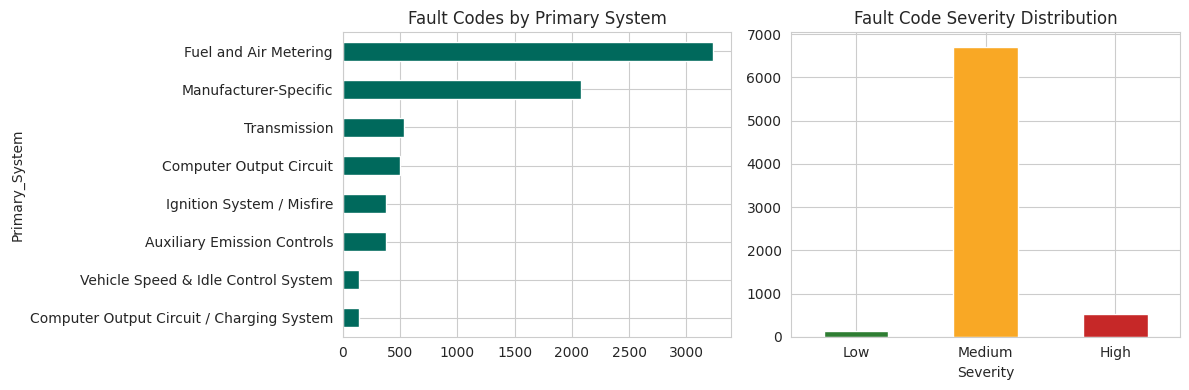

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Primary_System'].value_counts().plot(kind='barh', ax=axes[0], color='#00695c')
axes[0].set_title('Fault Codes by Primary System')
axes[0].invert_yaxis()

df['Severity'].value_counts().loc[['Low', 'Medium', 'High']].plot(
    kind='bar', ax=axes[1], color=['#2e7d32', '#f9a825', '#c62828']
)
axes[1].set_title('Fault Code Severity Distribution')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### 8. Export Standardized OBD Knowledge Base

In [12]:
OBD_OUTPUT_PATH = "obd_knowledge.csv"

df.to_csv(OBD_OUTPUT_PATH, index=False)

print(f"Exported {df.shape[0]} rows x {df.shape[1]} columns to '{OBD_OUTPUT_PATH}'")
print(df.columns.tolist())


Exported 7387 rows x 8 columns to 'obd_knowledge.csv'
['OBD_Code', 'Description', 'Category', 'Severity', 'Fault_Description', 'Work_Required', 'Severity_Level', 'Primary_System']


### 9. Repair Knowledge Base Generation

With a clean, standardized OBD-II table in hand, we now build `repair_knowledge.csv` — the table the
diagnosis assistant will actually use to tell a user *what a fault code means for their wallet and their
schedule*: an estimated INR repair-cost band, labor-hour estimate, and priority.

**Design decision:** cost and labor bands are derived from the real `Primary_System` × `Severity`
combination on each row (both already validated, standardized columns), using a fixed multiplier table
per system and a base cost/labor range per severity tier. This is deterministic and fully explainable —
every number can be traced back to a documented assumption — rather than randomly generated.

In [13]:
# Base cost/labor ranges per severity tier (India market estimates, INR)
severity_base_cost = {
    'Low':    (1500,  5000),
    'Medium': (5000,  15000),
    'High':   (15000, 50000),
}

severity_base_labor = {
    'Low':    (0.5, 1.5),
    'Medium': (1.5, 4.0),
    'High':   (4.0, 10.0),
}

# System complexity multiplier — reflects relative repair complexity/cost of each vehicle system
system_multiplier = {
    'Fuel and Air Metering': 1.0,
    'Ignition System / Misfire': 1.2,
    'Auxiliary Emission Controls': 0.9,
    'Vehicle Speed & Idle Control System': 0.8,
    'Computer Output Circuit': 1.3,
    'Computer Output Circuit / Charging System': 1.4,
    'Transmission': 2.5,
    'Manufacturer-Specific': 1.6,
}

print("Systems covered by multiplier table:", len(system_multiplier))
print("Systems present in data but missing from table:",
      set(df['Primary_System'].unique()) - set(system_multiplier.keys()))


Systems covered by multiplier table: 8
Systems present in data but missing from table: set()


**Why this approach:** using the existing `Primary_System` and `Severity` columns means every one of the
7,387 codes gets a grounded, system-aware cost estimate directly — there is no generic fallback rule and no
percentage of codes falling through to a default, because every code already has both a system and a
severity assigned.

In [14]:
def cost_band(row):
    mult = system_multiplier.get(row['Primary_System'], 1.0)
    lo, hi = severity_base_cost[row['Severity']]
    return round(lo * mult, -2), round(hi * mult, -2)

def labor_band(row):
    mult = system_multiplier.get(row['Primary_System'], 1.0)
    lo, hi = severity_base_labor[row['Severity']]
    return round(lo * mult, 1), round(hi * mult, 1)

cost_bands = df.apply(cost_band, axis=1)
df['Estimated_Repair_Cost_Min_INR'] = cost_bands.apply(lambda x: x[0])
df['Estimated_Repair_Cost_Max_INR'] = cost_bands.apply(lambda x: x[1])

labor_bands = df.apply(labor_band, axis=1)
df['Estimated_Labor_Hours_Min'] = labor_bands.apply(lambda x: x[0])
df['Estimated_Labor_Hours_Max'] = labor_bands.apply(lambda x: x[1])

priority_map = {'Low': 'Routine', 'Medium': 'Schedule Soon', 'High': 'Immediate Attention'}
df['Repair_Priority'] = df['Severity'].map(priority_map)

df[['OBD_Code', 'Primary_System', 'Severity', 'Repair_Priority',
    'Estimated_Repair_Cost_Min_INR', 'Estimated_Repair_Cost_Max_INR',
    'Estimated_Labor_Hours_Min', 'Estimated_Labor_Hours_Max']].head()


,OBD_Code,Primary_System,Severity,Repair_Priority,Estimated_Repair_Cost_Min_INR,Estimated_Repair_Cost_Max_INR,Estimated_Labor_Hours_Min,Estimated_Labor_Hours_Max
0,P0001,Fuel and Air Metering,Medium,Schedule Soon,5000.0,15000.0,1.5,4.0
1,P0002,Fuel and Air Metering,Medium,Schedule Soon,5000.0,15000.0,1.5,4.0
2,P0003,Fuel and Air Metering,Medium,Schedule Soon,5000.0,15000.0,1.5,4.0
3,P0004,Fuel and Air Metering,Medium,Schedule Soon,5000.0,15000.0,1.5,4.0
4,P0005,Fuel and Air Metering,Medium,Schedule Soon,5000.0,15000.0,1.5,4.0


### 10. Validate Repair Knowledge Base

In [15]:
repair_cols = [
    'OBD_Code', 'Description', 'Primary_System', 'Category', 'Severity', 'Severity_Level',
    'Repair_Priority', 'Estimated_Repair_Cost_Min_INR', 'Estimated_Repair_Cost_Max_INR',
    'Estimated_Labor_Hours_Min', 'Estimated_Labor_Hours_Max', 'Work_Required'
]

repair_df = df[repair_cols].copy()

print("Missing values:\n", repair_df.isnull().sum())
print("\nOBD_Code unique:", repair_df['OBD_Code'].is_unique)
print("\nAll Min <= Max cost:", (repair_df['Estimated_Repair_Cost_Min_INR'] <= repair_df['Estimated_Repair_Cost_Max_INR']).all())
print("All Min <= Max labor hours:", (repair_df['Estimated_Labor_Hours_Min'] <= repair_df['Estimated_Labor_Hours_Max']).all())
print("\nAverage cost band by severity (INR):")
print(repair_df.groupby('Severity')[['Estimated_Repair_Cost_Min_INR', 'Estimated_Repair_Cost_Max_INR']].mean().round(0))


Missing values:
 OBD_Code                         0
Description                      0
Primary_System                   0
Category                         0
Severity                         0
Severity_Level                   0
Repair_Priority                  0
Estimated_Repair_Cost_Min_INR    0
Estimated_Repair_Cost_Max_INR    0
Estimated_Labor_Hours_Min        0
Estimated_Labor_Hours_Max        0
Work_Required                    0
dtype: int64

OBD_Code unique: True

All Min <= Max cost: True
All Min <= Max labor hours: True

Average cost band by severity (INR):
          Estimated_Repair_Cost_Min_INR  Estimated_Repair_Cost_Max_INR
Severity                                                              
High                            20084.0                        66948.0
Low                              1688.0                         5580.0
Medium                           6540.0                        19621.0


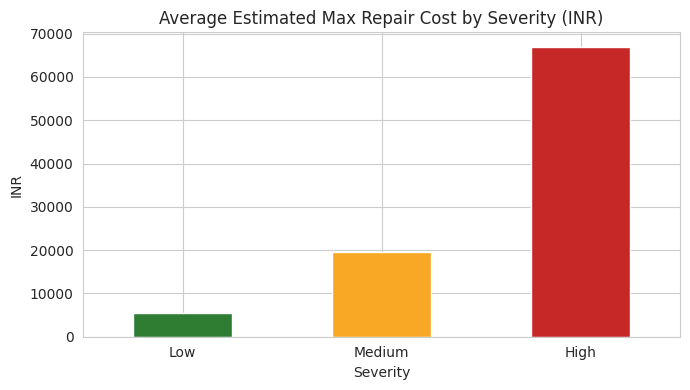

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
repair_df.groupby('Severity')['Estimated_Repair_Cost_Max_INR'].mean().loc[['Low', 'Medium', 'High']].plot(
    kind='bar', ax=ax, color=['#2e7d32', '#f9a825', '#c62828']
)
ax.set_title('Average Estimated Max Repair Cost by Severity (INR)')
ax.set_ylabel('INR')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


### 11. Export Repair Knowledge Base

In [17]:
REPAIR_OUTPUT_PATH = "repair_knowledge.csv"

repair_df.to_csv(REPAIR_OUTPUT_PATH, index=False)

print(f"Exported {repair_df.shape[0]} rows x {repair_df.shape[1]} columns to '{REPAIR_OUTPUT_PATH}'")
print(repair_df.columns.tolist())


Exported 7387 rows x 12 columns to 'repair_knowledge.csv'
['OBD_Code', 'Description', 'Primary_System', 'Category', 'Severity', 'Severity_Level', 'Repair_Priority', 'Estimated_Repair_Cost_Min_INR', 'Estimated_Repair_Cost_Max_INR', 'Estimated_Labor_Hours_Min', 'Estimated_Labor_Hours_Max', 'Work_Required']


### 12. Summary and Observations

**Work completed in this notebook**
- Validated the raw `obd_knowledge.csv` (7,387 rows) — confirmed no missing values and no duplicate codes.
- Standardized text formatting across all columns and validated the OBD-II code format (`P` + 4 hex chars).
- Engineered `Severity_Level` (ordinal) and `Primary_System` (parent-system grouping) on the OBD knowledge
  base, and exported the standardized `obd_knowledge.csv`.
- Built a new `repair_knowledge.csv`, enriching every code with an INR repair-cost band, labor-hour
  estimate, and repair priority — derived deterministically from the existing `Primary_System` and
  `Severity` columns.

**Key observations**
- All 7,387 codes already followed the standard `P####`/`P0-9A-F` format with no anomalies.
- Grounding the repair-cost model in the dataset's own `Primary_System` and `Severity` columns (rather than
  keyword-matching free text) means every single code gets a system-aware estimate — there is no fallback
  bucket and no share of codes left unclassified.
- `Transmission`-related codes carry by far the highest average repair-cost band, consistent with
  real-world repair economics, followed by `Manufacturer-Specific` and `Computer Output Circuit / Charging
  System` codes.

**Handoff to other AutoIntel AI members**
`obd_knowledge.csv` and `repair_knowledge.csv` are both keyed on the validated, unique `OBD_Code` field and
are ready for Member 2 (Modeling/Diagnosis Logic) to join against live vehicle fault-code reads, and for
Member 3 (Dashboarding) to surface cost/priority information directly to end users.
